# SentimentScope: Sentiment Analysis using Transformers!
## Introduction <a name = "introduction"></a>

In this notebook, you will train a transformer model from scratch to perform sentiment analysis on the IMDB dataset. You are a Machine Learning Engineer at Cinescope, a growing entertainment company working to enhance its recommendation system. Your task is to fine-tune a transformer-based model for sentiment analysis using the IMDB dataset. By classifying reviews as positive or negative, you will help the company better understand user sentiment and deliver more personalized experiences.

By completing this project, you will demonstrate your competency in the following learning objectives:

- Load, explore, and prepare a text dataset for training a transformer model using PyTorch.
- Customize the architecture of the transformer model for a classification task.
- Train and test a transformer model on the IMDB dataset.

Now that you have an overview of what you will achieve in this project, let’s move on to the project outline.

---

### Project Outline

This notebook is organized into the following sections:


1. [Introduction](#introduction): Overview of the project, learning objectives, and understanding sentiment analysis.
2. [Load, Explore, and Prepare the Dataset](#load-explore-and-prepare-the-dataset): Load the IMDB dataset, explore it with visualizations, and split it into training and validation sets.
3. [Implement a DataLoader in PyTorch](#implement-a-dataloader-in-pytorch): Create the `IMDBDataset` class and use it with the PyTorch `DataLoader`, including tokenization.
4. [Customize the Transformer Architecture](#customize-the-transformer-architecture): Modify the transformer model for binary classification.
5. [Implement Accuracy Calculation Method](#implement-accuracy-calculation-method): Create a function to compute accuracy for monitoring performance.
6. [Train the Model](#train-the-model): Complete and execute the training loop for binary classification.
7. [Test the Model](#test-the-model): Evaluate the model on the test dataset and ensure it achieves over 75% accuracy.
8. [Conclusion](#conclusion): Summarize the project results and key takeaways.

Click on the section titles above to navigate directly to the corresponding part of the notebook!

---

Now that we've outlined the structure and objectives of this project, let's delve into the core concept: sentiment analysis.

### Understanding Sentiment Analysis

Sentiment analysis is a natural language processing (NLP) technique used to determine the sentiment expressed in a piece of text. This can range from identifying the polarity (positive, negative, or neutral) of a review to analyzing emotions and opinions.

In this project, sentiment analysis is explicitly framed as a **binary classification task**, where the goal is to determine whether a given movie review is *positive* or *negative*. This task is central to many real-world applications, including customer feedback analysis, social media monitoring, and recommendation systems. By developing a transformer-based model, you will classify IMDB movie reviews as positive or negative to tackle the challenge faced by your entertainment company CineScope by enhancing its recommendation system, enabling more accurate and personalized suggestions.

Reviews labeled as positive will be marked as 1 in the dataset, while negative reviews will be labeled as 0.

For example, consider the following movie review:

> "The movie was a rollercoaster of emotions, and I loved every moment of it!"

This review is clearly positive as it expresses enjoyment and satisfaction with the movie, hence it will be labelled as *positive* or 1 in the dataset. In contrast:

> "The plot was predictable, and the acting was subpar. A waste of time."

This review conveys a negative sentiment, criticizing both the plot and acting, hence it will be labelled as *negative* or 0 in the dataset.

While transformers are often used for generation tasks, they can also be adapted for classification tasks with some modifications to their architecture. You might already be familiar with the tweaks that we will implement in this project.


---

### Data Description

The dataset used in this project is the [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/), provided in the `aclIMDB_v1.tar.gz` file. Upon extracting the file, you will find the following folder structure:

```
aclIMDB/
├── train/
│   ├── pos/    # Positive reviews for training
│   ├── neg/    # Negative reviews for training
│   ├── unsup/  # Unsupervised data (not used in this project)
├── test/
│   ├── pos/    # Positive reviews for testing
│   ├── neg/    # Negative reviews for testing
```

- **train/**: Contains labeled data for training the model. Reviews in the `pos/` folder should be labeled as positive (1), while reviews in the `neg/` folder should be labeled as negative (0).
- **test/**: Contains labeled data for evaluating the model. Similar to the training data, `pos/` and `neg/` contain positive and negative reviews, respectively.
- **unsup/**: Contains unlabeled reviews that are not used in this project.

Understanding the folder structure is crucial as it guides how we load and preprocess the data for the sentiment classification task.

---


## <a name="load-explore-and-prepare-the-dataset"></a>Load, Explore, and Prepare the Dataset

### 1. Load the Dataset
The dataset is already available in the environment as `aclIMDB_v1.tar.gz`. We will load it into Pandas DataFrames for easy exploration and preparation.


In [ ]:
import os
import pandas as pd

In [ ]:
!ls

'SentimentScope_starter (2).ipynb'   aclImdb_v1.tar.gz
 SentimentScope_starter__2_.zip


In [ ]:
# Unpack the dataset - uncomment the line below to run
#!tar -xzf aclImdb_v1.tar.gz

In [ ]:
!ls -ltrh aclImdb/test/neg

total 51M
-rw-r--r-- 1 ubuntu ubuntu 2.3K Apr 12  2011 9_4.txt
-rw-r--r-- 1 ubuntu ubuntu 1.1K Apr 12  2011 8_2.txt
-rw-r--r-- 1 ubuntu ubuntu 1.2K Apr 12  2011 7_1.txt
-rw-r--r-- 1 ubuntu ubuntu 1.9K Apr 12  2011 6_3.txt
-rw-r--r-- 1 ubuntu ubuntu 2.1K Apr 12  2011 5_4.txt
-rw-r--r-- 1 ubuntu ubuntu  981 Apr 12  2011 4_4.txt
-rw-r--r-- 1 ubuntu ubuntu 2.7K Apr 12  2011 46_2.txt
-rw-r--r-- 1 ubuntu ubuntu  834 Apr 12  2011 45_2.txt
-rw-r--r-- 1 ubuntu ubuntu  719 Apr 12  2011 44_4.txt
-rw-r--r-- 1 ubuntu ubuntu  883 Apr 12  2011 43_1.txt
-rw-r--r-- 1 ubuntu ubuntu 1.7K Apr 12  2011 42_4.txt
-rw-r--r-- 1 ubuntu ubuntu 3.0K Apr 12  2011 41_4.txt
-rw-r--r-- 1 ubuntu ubuntu 1013 Apr 12  2011 40_4.txt
-rw-r--r-- 1 ubuntu ubuntu  932 Apr 12  2011 3_4.txt
-rw-r--r-- 1 ubuntu ubuntu 3.0K Apr 12  2011 39_3.txt
-rw-r--r-- 1 ubuntu ubuntu 1.5K Apr 12  2011 38_1.txt
-rw-r--r-- 1 ubuntu ubuntu 1.2K Apr 12  2011 37_1.txt
-rw-r--r-- 1 ubuntu ubuntu  920 Apr 12  2011 36_3.txt
-rw-r--r-- 1 ubuntu ubunt

In [ ]:
!ls -ltrh aclImdb/train/

total 66M
-rw-r--r-- 1 ubuntu ubuntu 2.4M Apr 12  2011 urls_unsup.txt
-rw-r--r-- 1 ubuntu ubuntu 599K Apr 12  2011 urls_pos.txt
-rw-r--r-- 1 ubuntu ubuntu 599K Apr 12  2011 urls_neg.txt
-rw-r--r-- 1 ubuntu ubuntu  21M Apr 12  2011 labeledBow.feat
-rw-r--r-- 1 ubuntu ubuntu  40M Apr 12  2011 unsupBow.feat
drwxr-xr-x 2 ubuntu ubuntu 368K Jul 21 07:01 neg
drwxr-xr-x 2 ubuntu ubuntu 368K Jul 21 07:01 pos
drwxr-xr-x 2 ubuntu ubuntu 1.4M Jul 21 07:01 unsup


In [ ]:
!head -5 aclImdb/train/urls_pos.txt

http://www.imdb.com/title/tt0453418/usercomments
http://www.imdb.com/title/tt0453418/usercomments
http://www.imdb.com/title/tt0453418/usercomments
http://www.imdb.com/title/tt0064354/usercomments
http://www.imdb.com/title/tt0064354/usercomments


In [ ]:
!ls -ltrh aclImdb/train/neg

total 51M
-rw-r--r-- 1 ubuntu ubuntu  746 Apr 12  2011 9_1.txt
-rw-r--r-- 1 ubuntu ubuntu 1.3K Apr 12  2011 99_1.txt
-rw-r--r-- 1 ubuntu ubuntu 2.0K Apr 12  2011 98_1.txt
-rw-r--r-- 1 ubuntu ubuntu  826 Apr 12  2011 97_1.txt
-rw-r--r-- 1 ubuntu ubuntu  802 Apr 12  2011 96_1.txt
-rw-r--r-- 1 ubuntu ubuntu  852 Apr 12  2011 95_3.txt
-rw-r--r-- 1 ubuntu ubuntu 1.1K Apr 12  2011 94_1.txt
-rw-r--r-- 1 ubuntu ubuntu 2.2K Apr 12  2011 93_1.txt
-rw-r--r-- 1 ubuntu ubuntu  637 Apr 12  2011 92_3.txt
-rw-r--r-- 1 ubuntu ubuntu  758 Apr 12  2011 91_1.txt
-rw-r--r-- 1 ubuntu ubuntu 1.6K Apr 12  2011 90_4.txt
-rw-r--r-- 1 ubuntu ubuntu  824 Apr 12  2011 8_4.txt
-rw-r--r-- 1 ubuntu ubuntu 1.2K Apr 12  2011 89_2.txt
-rw-r--r-- 1 ubuntu ubuntu  632 Apr 12  2011 88_2.txt
-rw-r--r-- 1 ubuntu ubuntu  682 Apr 12  2011 87_4.txt
-rw-r--r-- 1 ubuntu ubuntu  718 Apr 12  2011 86_4.txt
-rw-r--r-- 1 ubuntu ubuntu 4.7K Apr 12  2011 85_2.txt
-rw-r--r-- 1 ubuntu ubuntu 1.2K Apr 12  2011 84_3.txt
-rw-r--r-- 1 ubuntu 

In [ ]:
!ls -ltrh aclImdb/train/pos |wc -l
!ls -ltrh aclImdb/train/neg |wc -l
!ls -ltrh aclImdb/test/pos |wc -l
!ls -ltrh aclImdb/test/neg |wc -l

12501
12501
12501
12501


In [ ]:
!cat aclImdb/train/pos/86_10.txt

I remember seeing this in a the Salem movie theater (where I used to attend "Kiddie Matinée"s almost every Saturday) in Dayton, Ohio when I was a young boy and have never forgotten it. It simply amazed me and my friends. I do wish there were some way I could see it again! I have tried to find some compilation of shorts or something like that to no avail. I only recently discovered that it was a Cousteau film and that blew my mind even more. How the heck he accomplished this is beyond my understanding. The fish is ACTUALLY IN THE CAT'S MOUTH at one point, if I remember correctly! If anyone could help me find a way to see it again I would be extremely grateful!

In [ ]:
!cat aclImdb/train/neg/97_1.txt

I have not seen many low budget films i must admit, but this is the worst movie ever probably, the main character the old man talked like, he had a lobotomy and lost the power to speak more than one word every 5 seconds, a 5 year old could act better. The story had the most awful plot, and well the army guy had put what he thought was army like and then just went over the top, i only watched it to laugh at how bad it was, and hoped it was leading onto the real movie. I cant believe it was under the 2 night rental thing at blockbusters, instead of a please take this for free and get it out of our sight. I think there was one semi decent actor other than the woman, i think the only thing OK with the budget was the make up, but they show every important scene of the film in the beginning music bit. Awful simply awful.

You have successfully extracted the folder. Go back to your workspace and explore the folder structure and find the relative paths for each of the following:
- Training positive reviews
- Training negative reviews
- Testing positive reviews
- Testing negative reviews

Assign the paths of these folders relative to the starter file in the variables below.


In [ ]:
# Define paths to dataset
train_pos_path = 'aclImdb/train/pos' # Path to the directory containing positive reviews from the training set
train_neg_path = 'aclImdb/train/neg' # Path to the directory containing negative reviews from the training set
test_pos_path = 'aclImdb/test/pos' # Path to the directory containing positive reviews from the test set
test_neg_path = 'aclImdb/test/neg' # Path to the directory containing negative reviews from the test set

Now, you will implement the `load_dataset()` function, which reads all text files in a specified folder and returns their content as a list of strings. This function is essential for loading and preprocessing the dataset in subsequent steps.

To implement this function:

1. **Use the `os` module**: Leverage Python's `os` module to list all files in the folder.
2. **Handle file paths**: Use `os.path.join()` to construct full paths for files, ensuring compatibility across operating systems.
3. **Read file content**: Open each file in read mode (`'r'`) using UTF-8 encoding to handle text properly.
4. **Aggregate results**: Append the content of each file to a list and return it.

### Key Points to Consider:
- Ensure that the function only processes text files (you may use file extensions for filtering if needed).
- Refer to the [os.listdir documentation](https://docs.python.org/3/library/os.html#os.listdir) for listing files in a directory.


In [ ]:
n = 0
cl = []
for fl in os.listdir(train_pos_path):
    n+=1
    fl = os.path.join(train_pos_path, fl)
    print(fl)
    with open(fl, 'r', encoding='utf-8') as f:
        cont = f.read()
        cl.append(cont)
    if n > 3:
        break


aclImdb/train/pos/4637_8.txt
aclImdb/train/pos/11183_7.txt
aclImdb/train/pos/2075_8.txt
aclImdb/train/pos/8190_10.txt


In [ ]:
print(cl[0])
!cat aclImdb/train/pos/6308_8.txt
print(f"\n############\n")
print(cl[-1])
!cat aclImdb/train/pos/5481_10.txt

The Israeli/Palestinian conflict persists and while the world may be aware of the violence surrounding the division of the two countries, few have a clue to the other aspect of the division - the group of people who want peace and work toward eradicating the separation. Eytan Fox, in THE BUBBLE ('Ha-Buah'), has created a much needed alternative viewpoint of the schism, electing to tell a story that contains some fine humor, a lot of love, and a taste of brutal reality. It is a window into a situation that begs for understanding.<br /><br />In Tel Aviv three close friends are roommates: Lulu (Daniela Virtzer), a beautiful young woman with strong opinions; Yali (Alon Friedman), a very 'out' gay young man who works in a popular café; and Noam (Ohad Knoller), a handsome, somewhat shy fellow who, in addition to his day job in a music shop, is a member of the National Guard and therefore spends his free time serving as a guard at the city's checkpoints. It is during one of these guard duty w

In [ ]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        folder (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """
    #TODO: Implement the function here
    cl = []
    for fl in os.listdir(folder):
        fl = os.path.join(folder, fl)
        with open(fl, 'r', encoding='utf-8') as f:
            cont = f.read()
            cl.append(cont)
    return cl

Use the function now to load the training and testing data:

In [ ]:
# Load training and testing data
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

In [ ]:
assert len(train_pos) == 12500
assert len(train_neg) == 12500
assert len(test_pos) == 12500
assert len(test_neg) == 12500

We can convert the data into pandas dataframes to make handling the datasets easier.

In [ ]:
# Create DataFrames
train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  The Israeli/Palestinian conflict persists and ...      1
1  "Pet Sematary" is an adaptation from the Steph...      1
2  Saying a film is depressing isn't necessarily ...      1
3  This is, without a shadow of a doubt, one of t...      1
4  Girlfight is a story about a troubled teen nam...      1


You can ensure that your datasets have loaded correctly by running the following code cell. No output means success!

In [ ]:
# Assert that both datasets have the expected number of rows
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

# Assert that both datasets have exactly two columns
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."


### 2. Explore the Dataset
Exploration helps us understand the dataset's structure and distribution.

Here are some suggestions for exploration and visualizations:
- **Dataset Overview**: Use `DataFrame.info()` and `DataFrame.describe()` to understand the dataset structure and basic statistics.
- **Label Distribution**: Create bar charts to visualize the number of positive and negative reviews.
- **Review Length Analysis**: Compute and plot the distribution of review lengths (e.g., number of characters or words).
- **Sample Reviews**: Print a few positive and negative reviews to understand the text content.

Write code to explore the dataset in this section.

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [ ]:
train_df['len_revw'] = train_df['review'].apply(lambda x: len(x.split()))

In [ ]:
train_df

,review,label,len_revw
0,The Israeli/Palestinian conflict persists and ...,1,464
1,"""Pet Sematary"" is an adaptation from the Steph...",1,499
2,Saying a film is depressing isn't necessarily ...,1,162
3,"This is, without a shadow of a doubt, one of t...",1,159
4,Girlfight is a story about a troubled teen nam...,1,171
...,...,...,...
24995,A phenomenal achievement in awfulness. It's ac...,0,498
24996,It seems the makers of this film had trouble d...,0,590
24997,Not even Goebbels could have pulled off a prop...,0,174
24998,This movie is truly brilliant. It ducks throug...,0,152


In [ ]:
train_df.describe()

,label,len_revw
count,25000.00000,25000.000000
mean,0.50000,233.787200
std,0.50001,173.733032
min,0.00000,10.000000
25%,0.00000,127.000000
50%,0.50000,174.000000
75%,1.00000,284.000000
max,1.00000,2470.000000


In [ ]:
#!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df["label"].value_counts().sort_index()

0    12500
1    12500
Name: label, dtype: int64

In [ ]:
def draw_bar(df):
    label_counts = df["label"].value_counts().sort_index()
    sns.barplot(
        x=["Negative", "Positive"],
        y=label_counts.values,
        palette=["tomato", "mediumseagreen"]
        )
    plt.title("Label Distribution")
    plt.xlabel("Review Sentiment")
    plt.ylabel("Number of Reviews")

    for i, v in enumerate(label_counts.values):
        plt.text(i, v + 100, str(v), ha="center")

    plt.show()

/tmp/ipykernel_3245/825487168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


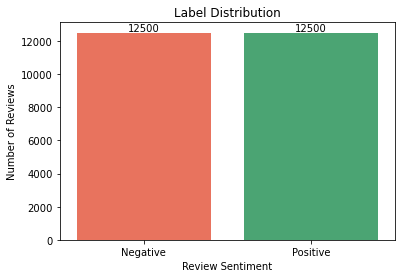

In [ ]:
draw_bar(train_df)

In [ ]:
def wrdcnt_anlysis(df):
    sns.set_style("whitegrid")
    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x="len_revw",
        bins=40,
        kde=True,
        color="steelblue"
    )

    plt.title("Distribution of Review Lengths")
    plt.xlabel("Review Length (Number of Words)")
    plt.ylabel("Frequency")

    plt.show()

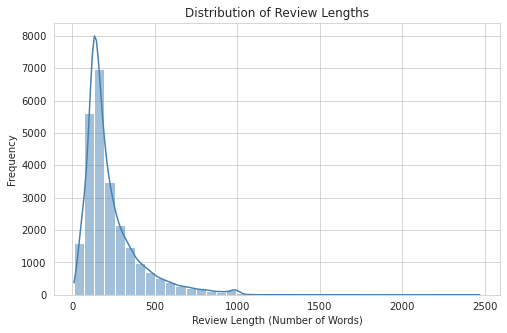

In [ ]:
wrdcnt_anlysis(train_df)

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [ ]:
test_df['len_revw'] = test_df['review'].apply(lambda x: len(x.split()))

In [ ]:
test_df.describe()

,label,len_revw
count,25000.00000,25000.000000
mean,0.50000,228.526680
std,0.50001,168.883693
min,0.00000,4.000000
25%,0.00000,126.000000
50%,0.50000,172.000000
75%,1.00000,277.000000
max,1.00000,2278.000000


/tmp/ipykernel_3245/825487168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


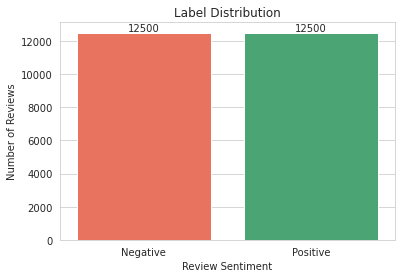

In [ ]:
draw_bar(test_df)

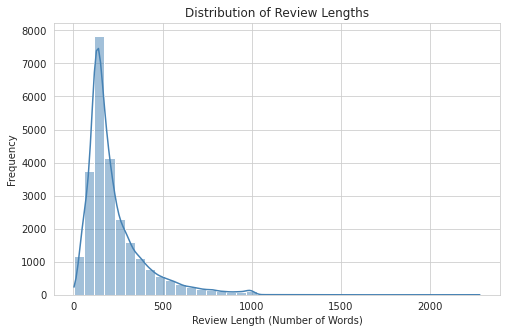

In [ ]:
wrdcnt_anlysis(test_df)

In [ ]:
train_df['len_revw'].quantile(0.92)

502.08000000000175

In [ ]:
test_df['len_revw'].quantile(0.92)

490.0

In [ ]:
#Based on the analysis above 512 token length should be a good cut-off point in my opinion as it covers 92% examples fully

In [ ]:
import random
random.sample(train_df[train_df['label']==1]['review'].tolist(), 3)

['This movie (with the alternate title "Martial Law 3" for some reason) introduced me to Jeff Wincott for the first time. And it was a great introduction. Although I had never heard of him before, he seemed to be an excellent fighter. The action scenes in this movie are GREAT! There are lots of them too, by the way. The recruit fight at the Peacekeepers HQ is especially good. There\'s just something about one single guy beating the crap out of a bunch of people that\'s really fun. And for the rest of the cast: Brigitte Nielsen was a good choice for the villain. Roles like this fits her (but others don\'t). Matthias Hues also did a good job, as always. He\'s a great fighter and macho-like character, and was a good rival for Wincott in this movie.',
 "I gave this film 10 not because it is a superbly consistent movie, but for it's pure ability to evoke emotions in its audience. The story of one-woman's-struggle-against-all-odds is an old cliché by now, but very few films have carried it o

In [ ]:
def display_rvw(df):
    pos_samples = random.sample(df[df['label']==1]['review'].tolist(), 3)
    neg_samples = random.sample(df[df['label']==0]['review'].tolist(), 3)
    print("#"*80)
    print("Positive Samples")
    print("#"*80)
    for sample in pos_samples:
        print(sample)
        print("#"*80)
    print("#"*80)
    print("Negative Samples")
    print("#"*80)
    for sample in neg_samples:
        print(sample)
        print("#"*80)

In [ ]:
display_rvw(train_df)

################################################################################
Positive Samples
################################################################################
and this IS a very disturbing film. I may be wrong, but this is the last film where I considered Burt Reynolds an actual actor, who transformed the role, and delivered a message.<br /><br />Jon Voight and Ned Beatty are also excellent. They are unassuming and unaware; businessmen wanting to enjoy the country. Little did they know what would happen next.<br /><br />The photography and sets are realistic and natural. This was before the days of Wes Craven.<br /><br />What is most disturbing about this film is the fact that places like this still exist. In America, country folk still detest city people; it is almost a century and a half since the Civil War.<br /><br />You will enjoy this film. It was filmed in the rural sections of South Georgia, which still exist. Just don't drive past that to Mobile, Alabama; T

In [ ]:
display_rvw(test_df)

################################################################################
Positive Samples
################################################################################
I happened upon this by chance. I was at my friends house and he had just started watching it, so I sat down thinking we would shoot the breeze whilst this was playing in the background. However, within seconds I was immersed in this docu-drama, and we both spent the rest of the time completely focused on this and not saying a word to each other. <br /><br />I never knew the tale of the the first solo around the world yacht race, let alone the tragic events of one man's attempt against the odds, which set out to be his redemption for all of his misfortunes in life, but ultimately ends up becoming an example of them. Having not known of the story, I did watch this with the same fervor as I imagine those who were reading about the race at the time it actually was happening, engulfed in what was taking place and 

### 3. Prepare the Dataset
We will split the training data further into training and validation subsets. The way we constructed the dataset, reviews with positive and negative labels are segregated. To ensure that the validation dataset works well, we first need to shuffle the dataset.


In [ ]:
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))
# Shuffle the dataset
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

In [ ]:
len(train_data), train_data

(22500,
                                                   review  label  len_revw
 0      (Question) What do you call 100 film critics b...      1       176
 1      True, there are many movies much worse then th...      0       722
 2      " Domino " has been widely condemned on this s...      1       481
 3      I will be short...This film is an embarrassmen...      0       165
 4      Slaughter High is intrinsically your emblemati...      0       329
 ...                                                  ...    ...       ...
 22495  Well, if you are open-minded enough to have li...      1       126
 22496  Contrary to most other comments about "Syriana...      0       208
 22497  A truly dreadful film. I did not know initiall...      0       183
 22498  This a superb self-contained work that is unco...      1        97
 22499  This film makes a strong comment about the Ita...      1       130
 
 [22500 rows x 3 columns])

In [ ]:
len(val_data), val_data

(2500,
                                                   review  label  len_revw
 22500  Here's an excellent Barbara Stanwyck double bi...      1       509
 22501  I love watching Jerry as much as the rest of t...      0        63
 22502  I would just like it to be known, that I do no...      0       243
 22503  Gung Ho is one of those movies that you will w...      1       130
 22504  Okay, this show is nothing but AWESOME! It has...      1       143
 ...                                                  ...    ...       ...
 24995  "A Guy Thing" tries to capture the feeling of ...      0       195
 24996  I was surprised at just how much I enjoyed thi...      1       388
 24997  Please see also my comment on Die Nibelungen p...      1       501
 24998  Gods...where to start. I was only able to stom...      0       419
 24999  Bizarre Tobe Hooper exercise regarding an unfo...      0       404
 
 [2500 rows x 3 columns])

### 4. Testing the Tokenizer

#### Subword Tokenization
In earlier tasks, you might have encountered character-level tokenization, where each character in the text is treated as a token. While this is straightforward, it is less efficient and may result in larger input sizes, impacting the performance of transformer models.

To address this, we will use Hugging Face's `AutoTokenizer`, a robust and efficient class designed for tokenizing text based on pretrained models. Specifically, we will utilize the `bert-base-uncased` tokenizer, which applies **subword tokenization**. Subword tokenization involves two steps:

1. **Subword Splitting**: Words are split into smaller components (subwords) based on a predefined vocabulary. For example:
   - Input: "unhappiness"
   - Subword Splits: `['un', 'happiness']`

2. **Token Conversion**: Each subword is then converted into a numerical token ID. For example:
   - Subword Splits: `['un', 'happiness']`
   - Token IDs: `[1011, 24123]` (values are illustrative and depend on the tokenizer vocabulary).

#### About the `bert-base-uncased` Tokenizer
The `bert-base-uncased` tokenizer, developed by Google researchers, is part of the BERT model family. This tokenizer is associated with the `bert-base-uncased` model, which has been widely used for tasks such as sentiment analysis, question answering, and text classification. The tokenizer ensures all text is converted to lowercase and accents are removed, reducing vocabulary size and improving generalization. Example:

- Input: "I Love Transformers."
- Subword Splits: `['i', 'love', 'trans', '##formers', '.']`

You can learn more about the tokenizer and model on [Hugging Face's bert-base-uncased page](https://huggingface.co/bert-base-uncased).

#### Using the `AutoTokenizer` Class
The `AutoTokenizer` class in the Hugging Face Transformers library provides a seamless way to load tokenizers for various pretrained models. It automatically selects the correct tokenizer configuration based on the model name.


In [ ]:
!pip install transformers==4.50.1

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 39.2 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.5/793.5 KB 103.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 KB 124.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 206.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 KB 120.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.7/676.7 KB 139.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 205.6 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This initializes a tokenizer tailored for the `bert-base-uncased` model. You can refer to the [Hugging Face AutoTokenizer documentation](https://huggingface.co/docs/transformers/main_classes/tokenizer) for more details. You can find the definition of the `from_pretrained()` method [here](https://huggingface.co/docs/transformers/v4.48.0/en/model_doc/auto#transformers.AutoTokenizer.from_pretrained).

Instead of tokenizing the entire dataset, we will test the tokenizer on a few sample reviews directly from the dataset:


In [ ]:
# Take sample inputs from the dataset
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

In [ ]:
print(tokenized_samples)

{'input_ids': tensor([[  101,  1996,  2711,  1005,  1055,  7615,  2008,  2056,  2008,  6986,
          9923,  2003,  4763,  1998,  2010,  2565,  2003,  4763,  2038,  2498,
          2000, 12826,  2054,  4763,  1998, 19556,  2003,  1012,  2010,  6210,
          1997,  4763,  2003,  1996,  4500,  1997,  4763,  1012,  1996,  6331,
          2993,  2758,  2008,  1999,  1996,  2197,  2420,  2111,  2097,  2655,
          2204,  4763,  1998,  4763,  2204,   999,  2002,  2987,  1005,  1056,
          2130,  2113,  2008,  2002, 16829,  6331, 14951,   999,  2065,  2017,
          2123,  1005,  1056,  2113,  2643,  1998, 10214,  2000,  2113,  2032,
          2085,  1010,  2008,  1005,  1055,  3100,  1012,  2002,  2145,  7459,
          2017,  2021,  2043,  2017,  2079,  2633,  6812,  2115,  6181,  2000,
          2032,  1010,  1998,  2017,  2097,  1010,  2009,  2097,  2022,  2205,
          2397,  2005,  2017,  1012,  2643, 10255,  2053,  2028,  2000,  3109,
          1010,  2025,  2130,  2017,  

Explanation of parameters:
 - `truncation=True`: Truncates text longer than the specified max_length.
 - `padding=True`: Pads shorter sequences to match max_length.
 - `max_length=128`: Specifies the maximum length of the sequences.
 - `return_tensors="pt"`: Returns PyTorch tensors as the output format.

For more details about truncation and padding, refer to the [Hugging Face Padding and Truncation Documentation](https://huggingface.co/docs/transformers/pad_truncation). This step ensures that the tokenizer works as expected and provides insight into its behavior. Next, we will use the tokenizer within the class definition to process the dataset.

---


# Implement a DataLoader in PyTorch<a id="implement-a-dataloader-in-pytorch"></a>


In this section, you will implement a custom dataset class and use it to create a DataLoader in PyTorch for feeding data into the model during training. PyTorch simplifies this process by providing the `Dataset` and `DataLoader` classes, which handle batching, shuffling, and preprocessing, allowing you to focus on the model architecture and training.

To start, we will create a custom dataset class for the IMDB dataset, which will process and return tokenized inputs along with their corresponding labels. This class will use a tokenizer to preprocess the raw text data.

### 1. Define a Custom Dataset Class

The custom dataset class will inherit from `torch.utils.data.Dataset` and include the following features:

1. **Initialization (`__init__`)**:
   - Accepts raw text and label data, along with a tokenizer and a maximum sequence length.
   - The tokenizer is used to preprocess the text data into tokenized inputs.
   - The maximum sequence length ensures that all tokenized inputs are of uniform length.

2. **Length (`__len__`)**:
   - Returns the total number of data samples in the dataset.

3. **Item Retrieval (`__getitem__`)**:
   - Retrieves a single data point by index.
   - Preprocesses the text using the tokenizer to create tokenized input IDs.
   - Returns the tokenized input IDs and the corresponding label for the given index.

You can refer to [this](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) tutorial on the Pytorch website for more details.


In [ ]:
import torch
from torch.utils.data import Dataset
MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**NOTE ABOUT GPU USAGE**

The workspace provides you with access to a GPU which is necessary for training a transformer model due to the efficiency provided by GPUs on the large amount of computations that are required. To ensure judicious usage of limited resources, please usage the GPU only when you are training the model.

---
We will keep the maximum length of input to 128 tokens.

In [ ]:
MAX_LENGTH = 512

In [ ]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    This class preprocesses text data using a tokenizer and returns tokenized inputs
    along with their corresponding labels for sentiment analysis.

    Attributes:
        data (pd.DataFrame): A DataFrame containing text and label columns.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used for preprocessing text.
        max_length (int): Maximum length for tokenized sequences.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        """
        Initialize the dataset.

        Args:
            data (pd.DataFrame): A DataFrame with columns `review` (text) and `label` (target).
            tokenizer (transformers.PreTrainedTokenizer): The tokenizer to preprocess the text.
            max_length (int, optional): Maximum token sequence length. Defaults to 128.
        """
        #TODO: Write code to initialize the dataset
        self.reviews = data['review']
        self.labels = data['label']
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        #TODO: Write code to return the length of the dataset
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Retrieve a single data point by index and preprocess it.

        Args:
            idx (int): Index of the data point to retrieve.

        Returns:
            torch.Tensor: Tokenized input IDs for the text.
            int: Label corresponding to the text.
        """
        #TODO: Write code for the __getitem__() function
        input_toks = self.tokenizer(self.reviews.iloc[idx], truncation=True, padding="max_length", max_length=self.max_length, return_tensors="pt")['input_ids']
        input_label = int(self.labels.iloc[idx])
        return input_toks.squeeze(), input_label

### 2. Initialize the Dataset

Once the `IMDBDataset` class is defined, we can initialize it directly with the training and validation DataFrames.

In [ ]:
# Initialize the datasets
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

In [ ]:
train_dataset[0]

(tensor([  101,  1006,  3160,  1007,  2054,  2079,  2017,  2655,  2531,  2143,
          4401,  3950,  2039,  2000,  2037, 26082,  1999,  5472,  1029,  1006,
          3437,  1007,  1037,  2204,  2707,  1012,  2092,  1010,  1045,  2123,
          1005,  1056,  2113,  2848,  4717,  7416,  2013,  4205,  2021,  2065,
          2002,  2003,  1996, 13007,  4667,  8740,  2618,  3126,  2010,  2143,
          9888,  6083,  1010,  1000,  2293,  1999,  1996,  2051,  1997,  2769,
          1000,  2003,  1037,  1000,  2204,  2707,  1000,  1012,  1037,  2465,
          2100,  5607,  2007,  1059, 14341, 19570,  2389,  2189,  3482,  2806,
          2189,  1010,  2023, 17312,  3504,  2012,  1037,  4677,  1997,  2702,
          8918,  6550,  2004,  2009,  5829,  2013,  2711,  1037,  2000,  2711,
          1038,  2000,  2711,  1039,  1012,  1012,  1012,  4385,  1012,  1012,
          1012,  1998,  2067,  2153,  4566,  2007,  5381,  1037,  1004,  1038,
          1999, 27628,  4827,  1012,  1996,  2143,  

In [ ]:
train_dataset[0][0].shape

torch.Size([512])

In [ ]:
val_dataset[0]

(tensor([  101,  2182,  1005,  1055,  2019,  6581,  6437,  9761, 18418,  3600,
          3313,  3021,  2006,  2028,  5860,  1012,  1996,  2034,  3185,  1011,
          1998,  2903,  2033,  1996,  8276,  1997,  1996,  2048,  1011,  2003,
         15418,  1005,  1055,  1000,  2000,  3531,  1037,  3203,  1000,  1006,
          3925,  1007,  1999,  2029,  2016,  2003, 12739,  2007,  5215, 13733,
          1012,  2009,  2003,  7687,  1037,  2732,  4316,  2007, 13733,  2004,
          5156, 21949,  1996,  2143,  2007,  2010,  3898,  3739,  1012,  2182,
          2002,  3248,  1037, 24532,  2080,  3868,  4062,  2040,  4152,  2070,
          2919,  2811,  2013, 10469,  6398,  9761, 18418,  3600,  1998,  1996,
          2645,  1997,  1996, 21024,  4269,  1012,  1997,  2607,  2044,  2172,
          4748,  2080,  2027,  2776,  2203,  2039,  1999,  2169,  2500,  2608,
          1998,  2009,  2035,  3310,  2000,  1037, 21425,  1998, 24820,  2485,
          1012,  1037,  2978,  1997,  1037, 19857,  

In [ ]:
test_dataset[0]

(tensor([  101,  2748,  1010,  1045,  2113,  1010, 20996, 28147, 12098, 24204,
          2571,  2134,  1005,  1056,  2066,  2000,  2022,  2170,  1005, 19101,
          1005,  1010,  2021,  1045,  2481,  1005,  1056,  9507,  1996,  8257,
          1012,  1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,  2023,
          2003,  1037,  2986,  6746,  5226,  2460,  2013,  2010,  4672,  2558,
          1010,  2856,  2011, 20996, 28147,  1012,  1996,  2048,  2147,  2362,
          2007,  7167,  1997,  2204, 18201,  2015,  1998, 20996, 28147,  1005,
          1055,  5156,  3086,  2000,  1996,  4751,  1997,  5008,  1996,  3861,
          1999,  2019,  5875,  5450,  1012,  2087, 25119,  6871,  4257,  7497,
          1998,  1037,  2145,  4950,  2000,  2191,  2068,  2062,  5875,  1012,
         20996, 28147,  3594,  1037,  3232,  1997,  2146,  9651,  7171,  1998,
          2070,  3835,  4950,  7577,  7301,  2000,  2425,  2010,  2466,  1998,
          2000,  2265, 10654,  2004,  1037,  2986,  

### 3. Create a DataLoader

The `DataLoader` class in PyTorch helps manage batches of data during training. We will use it to create training and validation data loaders.

In [ ]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
text, label = next(iter(train_loader))
text.shape, label.shape

(torch.Size([32, 512]), torch.Size([32]))

In [ ]:
text, label = next(iter(val_loader))
text.shape, label.shape

(torch.Size([32, 512]), torch.Size([32]))

In [ ]:
text, label = next(iter(test_loader))
text.shape, label.shape

(torch.Size([32, 512]), torch.Size([32]))


You may have seen the use of `RandomShuffler` along with `DataLoader`. That approach is used when you want to train a model over a dataset randomly for a specified number of steps. In this model, we want to use the epoch approach.

An **epoch** is one complete pass through the entire dataset. When using the `DataLoader` in this setup, it ensures that every data point in the dataset is used exactly once during a single epoch. This approach is helpful for training models in a structured manner, ensuring that the model sees all the training examples and learns from them in each epoch before moving to the next one.

By setting `shuffle=True` for the `train_loader`, the data points are randomly shuffled at the start of each epoch, improving the generalization of the model. You will see this in action later in the code for training the model.

---
Given below are some assert statements to check your custom dataset and data loader definitions.

In [ ]:
assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

import numpy as np

# Check the first item in the train dataset
input_ids, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"

# Ensure the input IDs tensor has the correct shape
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

## <a id="customize-the-transformer-architecture"></a>Customize the Transformer Architecture

In this section, you will customize the transformer architecture to suit the task of binary classification. You may have used a similar architecture in the past for generation tasks. But you will need to make a few tweaks specifically in the `DemoGPT` class to adapt it for the binary classification.

### 1. Config Dictionary
Your config dictionary bundles all hyperparameters and model settings in one place. Below is the config that we will use in our model:

In [ ]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 512,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 8,
    "head_size": 64,  # 8 heads * 64 = 512 -> matches d_embed
    "dropout_rate": 0.5,
    "use_bias": True
}

Key Config Parameters:
- `vocabulary_size`: The total number of tokens in your vocabulary.
- `num_classes`: The number of classes for the classification head (2 = binary).
- `d_embed`: Dimensionality of embeddings (and hidden layers).
- `context_size`: Maximum sequence length for each input.
- `layers_num`: Number of stacked transformer blocks.
- `heads_num`: Number of attention heads in multi-head attention.
- `head_size`: Dimension of each attention head (must satisfy heads_num * head_size = d_embed).
- `dropout_rate`: Probability of dropping units during training to reduce overfitting.
- `use_bias`: Whether linear layers should have bias terms.



### 2. Class Definitions

Below are the class definitions you will work with. These classes form the core components of the transformer model. You may have seen these before, with the exception of the `DemoGPT` class which will need to be customized.


#### AttentionHead

In [ ]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        # Casual Mask
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

Here we use a dummy input aligned with our config:

- Batch size = `BATCH_SIZE` (32)
- Sequence length = `config["context_size"]` (128)
- Embedding dimension = `config["d_embed"]` (128)


In [ ]:
# Instantiate the AttentionHead
attention_head = AttentionHead(config).to(device)

# Create a dummy input of shape (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
attention_output = attention_head(dummy_input)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 512, 64])


Expected shape:

>`(B,T,head_size)=(32,128,32)`

#### MultiHeadAttention


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [ ]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Same dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 512, 512])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### FeedForward


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [ ]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 512, 512])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### Block


In [ ]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [ ]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 512, 512])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### DemoGPT
Below is the starter code for the `DemoGPT` class, which implements the core of a transformer model tailored for a binary classification task. This implementation builds on the foundation of a transformer architecture and includes the necessary modifications to adapt it for classification.

### Key Changes for Binary Classification

To adapt the transformer for classification, the following changes are required:

1. **Add a Classification-Specific Output Layer**:
   - The model needs a linear layer to map the final pooled embeddings to the number of classes.
   - The classification head is implemented using [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) with:
     - `in_features` set to `d_embed` (the embedding dimension).
     - `out_features` set to `num_classes` (the number of classes, 2 for binary classification).
     - `bias` set to `False` (optional; bias can be excluded to slightly simplify computations).


2. **Implement a Pooling Mechanism**:

   - Transformers output embeddings for each token in the input sequence. For classification, these token-level embeddings need to be condensed into a single vector.

   - A **mean pooling operation** is applied using [`torch.mean`](https://pytorch.org/docs/stable/generated/torch.mean.html) across the time dimension (`dim=1`) to aggregate token-level embeddings into a single representation vector.

In [ ]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        # Token embedding layer: Maps token indices to embedding vectors.
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])

        # Positional embedding layer: Adds positional information to the embeddings.
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])

        # Transformer layers: Stacked sequence of transformer blocks.
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)

        # Layer normalization: Applied to stabilize training.
        self.layer_norm = nn.LayerNorm(config["d_embed"])

        # TODO: Implement classification output layer - Maps pooled embeddings to class logits.
        self.out = nn.Linear(config["d_embed"], config["num_classes"])

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T),
                                    where B is the batch size, and T is the sequence length.

        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        # Step 1: Create embeddings for tokens and their positions
        x = self.token_embedding_layer(token_ids)  # Shape: (B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)  # Shape: (T,)
        pos_embed = self.positional_embedding_layer(positions)  # Shape: (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  # Add positional embeddings to token embeddings

        # Step 2: Pass embeddings through transformer layers
        x = self.layers(x)  # Shape: (B, T, d_embed)
        x = self.layer_norm(x)  # Normalize across the feature dimension

        # Step 3: TODO: Apply mean pooling across the time dimension  # Shape: (B, d_embed)
        x = x.mean(dim=1)

        # Step 4: TODO: Generate logits for classification  # Shape: (B, num_classes)
        logits = self.out(x)

        return logits

In [ ]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"],
    (BATCH_SIZE, config["context_size"])
).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[-0.0696, -0.0327],
        [-0.0594, -0.0710]], device='cuda:0', grad_fn=<SliceBackward0>)


Expected shape:

> `(B,num_classes)=(32,2)`


In [ ]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method <a name="implement-accuracy-calculation-method"></a>

In this section, you will learn how to calculate the validation accuracy for the transformer model on the IMDB dataset. Validation accuracy provides a performance metric that helps assess how well the model generalizes to unseen data during training.

### 1. Overview
The function to calculate validation accuracy will:

- Evaluate the model on the validation dataset.
- Generate predictions for each batch.
- Compare predictions with the true labels.
- Compute the percentage of correctly classified examples.

### 2.  Key Points
- **Evaluation Mode**: Calling `model.eval()` ensures that dropout and other training-specific layers are disabled during evaluation.
- **No Gradients**: The `torch.no_grad()` context disables gradient computation, reducing memory usage and speeding up validation.
- **Predictions**: `torch.argmax(logits, dim=1)` retrieves the index of the highest logit for each sample, which corresponds to the predicted class label.
- **Accuracy Calculation**: The function computes the fraction of correct predictions out of the total number of samples, then multiplies by 100 to express it as a percentage.

After calculating the validation accuracy, incorporate this function into your training loop. Typically, you would call calculate_accuracy at the end of each epoch or after a specific number of training steps. Monitoring validation accuracy over time helps you track performance gains and identify potential overfitting or underfitting issues.

In [ ]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on the validation dataset.

    Args:
        model (torch.nn.Module): The trained transformer model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run the model (e.g., 'cuda' or 'cpu').

    Returns:
        float: Validation accuracy as a percentage.
    """
    total_correct = 0
    total_samples = len(data_loader.dataset)
    model.eval()
    for inp, label in data_loader:
        inp, label = inp.to(device), label.to(device)
        with torch.no_grad():
            logits = model(inp)
        out = torch.argmax(logits, dim=1)
        total_correct += (out == label).sum().item()

    accuracy = (total_correct / total_samples) * 100
    model.train()
    return accuracy

In [ ]:
model = DemoGPT(config).to(device)

In [ ]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 51.04%


As you can see, the validation accuracy is close to 50%. This is expected as the model's parameters have been initialized randomly.

## Train the Model <a name="train-the-model"></a>

In this section, we will define the training loop for the transformer-based model designed for sentiment analysis. The training loop is crucial for optimizing the model's weights and biases to minimize the loss function and improve classification performance.

### Training Loop

The training loop will involve the following steps:

1. **Iterate through epochs**: Repeat the training process for a predefined number of epochs.
2. **Load batches of data**: Use the `DataLoader` to retrieve batches of input IDs and labels.
3. **Forward pass**: Compute the logits by passing the input IDs through the model.
4. **Compute loss**: Use cross-entropy loss as the criterion.
5. **Backward pass and optimization**: Backpropagate the loss and update the model parameters using the optimizer.
6. **Validation**: Calculate the validation accuracy after each epoch.


In [ ]:
import torch.optim as optim

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
EPOCHS = 10

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

# Training loop
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # TODO: Implement forward pass
        logits = model(input_ids)

        # TODO: Calculate loss
        loss = criterion(logits, labels)

        # TODO: Set gradients to zero
        optimizer.zero_grad()

        # TODO: Backward pass
        loss.backward()

        # TODO: Step the optimizer
        optimizer.step()

        running_loss += loss.item()

        out = torch.argmax(logits, dim=1)
        running_acc += (out == labels).sum().item()


        # Log training progress
        if (step + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}")
            running_loss = 0.0
    print(f"End of Epoch [{epoch+1}/{EPOCHS}] Training Accuracy: {running_acc/len(train_loader.dataset):.4f}")

    # Evaluate validation accuracy
    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/10], Step [100/704], Loss: 0.7223
Epoch [1/10], Step [200/704], Loss: 0.6218
Epoch [1/10], Step [300/704], Loss: 0.5396
Epoch [1/10], Step [400/704], Loss: 0.5122
Epoch [1/10], Step [500/704], Loss: 0.4781
Epoch [1/10], Step [600/704], Loss: 0.4373
Epoch [1/10], Step [700/704], Loss: 0.4170
End of Epoch [1/10] Training Accuracy: 0.7167
Epoch 1 - Validation Accuracy: 80.76%
Epoch [2/10], Step [100/704], Loss: 0.3732
Epoch [2/10], Step [200/704], Loss: 0.3610
Epoch [2/10], Step [300/704], Loss: 0.3861
Epoch [2/10], Step [400/704], Loss: 0.3657
Epoch [2/10], Step [500/704], Loss: 0.3587
Epoch [2/10], Step [600/704], Loss: 0.3375
Epoch [2/10], Step [700/704], Loss: 0.3258
End of Epoch [2/10] Training Accuracy: 0.8438
Epoch 2 - Validation Accuracy: 82.84%
Epoch [3/10], Step [100/704], Loss: 0.2900
Epoch [3/10], Step [200/704], Loss: 0.2771
Epoch [3/10], Step [300/704], Loss: 0.2870
Epoch [3/10], Step [400/704], Loss: 0.2871
Epoch [3/10], Step [500/704], Loss: 0.2670
Epoch [3/10], S

#### Notes

- The `evaluate_accuracy` function calculates the model's accuracy on the validation dataset. Ensure this function is defined and works as expected.
- The training progress is logged every 100 steps to monitor performance.
- After each epoch, the validation accuracy is printed to ensure the model generalizes well to unseen data.


## Test the Model <a name="test-the-model"></a>

In this section, you will evaluate the performance of your trained transformer model on the test dataset. Testing the model involves loading the test dataset, passing it through the model, and calculating the accuracy.

In [ ]:
# TODO: Calculate the accuracy of the model over the test set using the calculate_accuracy() function
# Evaluate validation accuracy
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Epoch {epoch+1} - Test Accuracy: {test_accuracy:.2f}%")

Epoch 10 - Test Accuracy: 81.08%



With the accuracy calculated, you can verify if the model meets the project goal of achieving greater than 75% accuracy on the test dataset.

Try training your model for more than 3 epochs! Try increasing the size of the embedding used in the model. Or try increasing the number of blocks or layers in the model. You may be able to improve the accuracy of your model further!


### TAKE 2 Disabling causal masking thereby making it an encoder architecture plus introducing dropout before classification layer

In [ ]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 512,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 8,
    "head_size": 64,  # 8 heads * 16 = 128 -> matches d_embed
    "dropout_rate": 0.5,
    "use_bias": True
}

In [ ]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        #casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        #self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        # Casual Mask
        #attention_scores = attention_scores.masked_fill(
        #    self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
        #    float('-inf')
        #)
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [ ]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [ ]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        # Token embedding layer: Maps token indices to embedding vectors.
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])

        # Positional embedding layer: Adds positional information to the embeddings.
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])

        # Transformer layers: Stacked sequence of transformer blocks.
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)

        # Layer normalization: Applied to stabilize training.
        self.layer_norm = nn.LayerNorm(config["d_embed"])
        self.dropout = nn.Dropout(0.4)
        self.bn = nn.BatchNorm1d(config["d_embed"])
        self.relu = nn.ReLU(inplace=True)
        # TODO: Implement classification output layer - Maps pooled embeddings to class logits.
        self.out = nn.Linear(config["d_embed"], config["num_classes"])

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T),
                                    where B is the batch size, and T is the sequence length.

        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        # Step 1: Create embeddings for tokens and their positions
        x = self.token_embedding_layer(token_ids)  # Shape: (B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)  # Shape: (T,)
        pos_embed = self.positional_embedding_layer(positions)  # Shape: (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  # Add positional embeddings to token embeddings

        # Step 2: Pass embeddings through transformer layers
        x = self.layers(x)  # Shape: (B, T, d_embed)
        x = self.layer_norm(x)  # Normalize across the feature dimension

        # Step 3: TODO: Apply mean pooling across the time dimension  # Shape: (B, d_embed)
        x = x.mean(dim=1)
        x = self.bn(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Step 4: TODO: Generate logits for classification  # Shape: (B, num_classes)
        logits = self.out(x)

        return logits

In [ ]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"],
    (BATCH_SIZE, config["context_size"])
).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[0.8803, 0.0133],
        [0.2855, 0.3158]], device='cuda:0', grad_fn=<SliceBackward0>)


In [ ]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

In [ ]:
import torch.optim as optim

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
EPOCHS = 10

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

# Training loop
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # TODO: Implement forward pass
        logits = model(input_ids)

        # TODO: Calculate loss
        loss = criterion(logits, labels)

        # TODO: Set gradients to zero
        optimizer.zero_grad()

        # TODO: Backward pass
        loss.backward()

        # TODO: Step the optimizer
        optimizer.step()

        running_loss += loss.item()

        out = torch.argmax(logits, dim=1)
        running_acc += (out == labels).sum().item()


        # Log training progress
        if (step + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}")
            running_loss = 0.0
    print(f"End of Epoch [{epoch+1}/{EPOCHS}] Training Accuracy: {running_acc/len(train_loader.dataset):.4f}")

    # Evaluate validation accuracy
    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/10], Step [100/704], Loss: 0.6742
Epoch [1/10], Step [200/704], Loss: 0.5418
Epoch [1/10], Step [300/704], Loss: 0.5065
Epoch [1/10], Step [400/704], Loss: 0.4660
Epoch [1/10], Step [500/704], Loss: 0.4402
Epoch [1/10], Step [600/704], Loss: 0.4136
Epoch [1/10], Step [700/704], Loss: 0.4086
End of Epoch [1/10] Training Accuracy: 0.7595
Epoch 1 - Validation Accuracy: 82.24%
Epoch [2/10], Step [100/704], Loss: 0.3316
Epoch [2/10], Step [200/704], Loss: 0.3349
Epoch [2/10], Step [300/704], Loss: 0.3351
Epoch [2/10], Step [400/704], Loss: 0.3584
Epoch [2/10], Step [500/704], Loss: 0.3370
Epoch [2/10], Step [600/704], Loss: 0.3175
Epoch [2/10], Step [700/704], Loss: 0.3153
End of Epoch [2/10] Training Accuracy: 0.8621
Epoch 2 - Validation Accuracy: 80.12%
Epoch [3/10], Step [100/704], Loss: 0.2348
Epoch [3/10], Step [200/704], Loss: 0.2825
Epoch [3/10], Step [300/704], Loss: 0.2543
Epoch [3/10], Step [400/704], Loss: 0.2637
Epoch [3/10], Step [500/704], Loss: 0.2900
Epoch [3/10], S

In [ ]:
# TODO: Calculate the accuracy of the model over the test set using the calculate_accuracy() function
# Evaluate validation accuracy
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Epoch {epoch+1} - Test Accuracy: {test_accuracy:.2f}%")

Epoch 10 - Test Accuracy: 83.63%


## Conclusion <a name="conclusion"></a>

 TODO:
 1. Summarize the project results
 2. List key takeaways

Project Result Summary:
1) Model was trained using given decoder based architecture for 10 epochs.
2) We also trained by converting it into encoder architecture for 10 epochs.
3) While training accuracy can be seen to breach 95% mark, validation accuracy could not go beyond 86%
4) Final test accuracy using both the methods are 81.08% and 83.63% which meets the evaluation criteria.

Key Takeaways:
1) Model is overfitting on training data.
2) This is because of the inability of model to generalize well on test and validation data. This is further due to fact that transformers are data hungry model and need more data to be able to generalize well on test data. Still test accuracy of 81+ looks good considering we are training model from scratch
3) Other steps that can be taken here to optimize the results are :
    - train the tokenizer on the train data and reduce the vocabulary size. This will reduce model size.
    - Perform masked language modeling first followed by model training using encoder architecture. Our model is decoder based.This can easily be done by ignoring masking instructions in code.
4) We also tried training by ignoring masking instructions, results improved but a 2% increase does not show significant improvement though it shows we moved in a positive direction. We also tried increasing dropout rate to 0.5 but that did not help reduce the deficit between training and test results
